# Plant Disease Classification - Jupyter Notebook

Uses Kaggle dataset: `emmarex/plantdisease`.

This version does **not** assume `./data/train` and `./data/test` already exist. It downloads/extracts the dataset, finds the class folders automatically, then creates train/validation/test splits.

In [1]:
# CELL 1: Install packages
import sys, subprocess, pkgutil

packages = ["kaggle", "tqdm", "scikit-learn", "matplotlib", "pandas", "numpy", "torch", "torchvision"]
for p in packages:
    mod = p.replace("scikit-learn", "sklearn")
    if pkgutil.find_loader(mod) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

print("Packages ready.")

Packages ready.


In [4]:
# CELL 2: Load Local Dataset (No Kaggle Download Needed)

from pathlib import Path
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import torch

DATASET_PATH = r"C:\Users\santosh\Downloads\data\PlantVillage\PlantVillage"

dataset_path = Path(DATASET_PATH)

print("Checking dataset path...")
print("Path exists:", dataset_path.exists())

print("\nClasses found:")
print([folder.name for folder in dataset_path.iterdir() if folder.is_dir()])

# Load full dataset
full_dataset = ImageFolder(root=DATASET_PATH)

print(f"\nTotal Images: {len(full_dataset)}")
print(f"Total Classes: {len(full_dataset.classes)}")
print(f"Class Names: {full_dataset.classes}")

# Split dataset
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nTrain Samples: {len(train_dataset)}")
print(f"Test Samples: {len(test_dataset)}")

Checking dataset path...
Path exists: True

Classes found:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']

Total Images: 20638
Total Classes: 15
Class Names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Train Samples: 16510
Test Samples: 4128


In [6]:
# CELL 3: Find image-folder root automatically

from pathlib import Path

DATA_DIR = Path(r"C:\Users\santosh\Downloads\data\PlantVillage\PlantVillage")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder: Path):
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in image_exts)

def find_imagefolder_root(base: Path):
    # Finds a folder where immediate subfolders are class folders containing images.
    candidates = []
    for folder in [base] + [p for p in base.rglob("*") if p.is_dir()]:
        subdirs = [s for s in folder.iterdir() if s.is_dir()]
        if len(subdirs) < 2:
            continue
        class_like = [s for s in subdirs if count_images(s) > 0]
        if len(class_like) >= 2:
            total = sum(count_images(s) for s in class_like)
            candidates.append((total, folder, len(class_like)))
    if not candidates:
        raise FileNotFoundError("Could not find class folders with images. Check dataset extraction.")
    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0]

total_images, ROOT_DIR, num_class_dirs = find_imagefolder_root(DATA_DIR)
print("ImageFolder root:", ROOT_DIR)
print("Class folders:", num_class_dirs)
print("Total images:", total_images)
print("First class folders:", [p.name for p in sorted(ROOT_DIR.iterdir()) if p.is_dir()][:10])

ImageFolder root: C:\Users\santosh\Downloads\data\PlantVillage\PlantVillage
Class folders: 15
Total images: 20638
First class folders: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Early_blight']


In [7]:
# CELL 4: Imports and device setup

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [8]:
# CELL 5: Dataset and train/validation/test split

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0   # Use 0 on Windows/Jupyter to avoid DataLoader issues

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_train_aug = ImageFolder(ROOT_DIR, transform=train_transform)
full_eval = ImageFolder(ROOT_DIR, transform=eval_transform)

class_names = full_eval.classes
num_classes = len(class_names)

n_total = len(full_eval)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset_aug, _, _ = random_split(full_train_aug, [n_train, n_val, n_test], generator=generator)

generator = torch.Generator().manual_seed(SEED)
_, val_subset, test_subset = random_split(full_eval, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_subset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Classes:", num_classes)
print("Train:", len(train_subset_aug), "Validation:", len(val_subset), "Test:", len(test_subset))
print("Sample classes:", class_names[:10])

Classes: 15
Train: 14446 Validation: 3095 Test: 3097
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


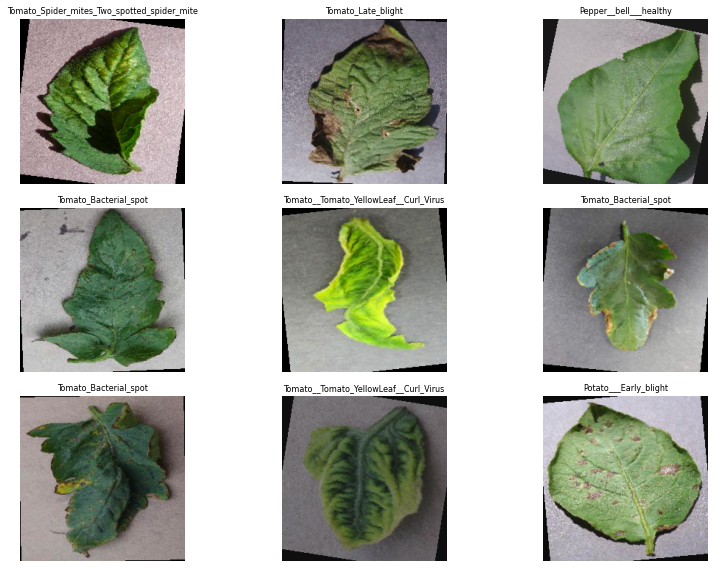

In [9]:
# CELL 6: Show sample images

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# CELL 7: Model - Transfer Learning with ResNet18

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

print(model.fc)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\santosh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 26.0MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=15, bias=True)
)
Trainable parameters: 7695


In [11]:
# CELL 8: Training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total


def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, total_correct / total, np.array(all_preds), np.array(all_labels)

In [12]:
# CELL 9: Train model

EPOCHS = 5
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_plant_disease_model.pth")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("Best validation accuracy:", round(best_val_acc, 4))

Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 01/5 | Train Loss: 1.2399 | Train Acc: 0.6317 | Val Loss: 0.6041 | Val Acc: 0.8452


Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 04/5 | Train Loss: 0.6357 | Train Acc: 0.7910 | Val Loss: 0.3938 | Val Acc: 0.8824


Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 05/5 | Train Loss: 0.6186 | Train Acc: 0.7966 | Val Loss: 0.3863 | Val Acc: 0.8834
Best validation accuracy: 0.8834


In [14]:
# CELL 10: Optional fine-tuning

FINE_TUNE = True
FINE_TUNE_EPOCHS = 1

if FINE_TUNE:
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    for epoch in range(FINE_TUNE_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_plant_disease_model.pth")

        print(f"Fine-tune Epoch {epoch+1:02d}/{FINE_TUNE_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("Best validation accuracy:", round(best_val_acc, 4))

Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

Fine-tune Epoch 01/1 | Train Loss: 0.3259 | Train Acc: 0.8922 | Val Loss: 0.1554 | Val Acc: 0.9506
Best validation accuracy: 0.9506


In [15]:
# CELL 11: Test-set evaluation

model.load_state_dict(torch.load("best_plant_disease_model.pth", map_location=device))

test_loss, test_acc, test_preds, test_labels = evaluate_model(model, test_loader, criterion, device)

print("=" * 70)
print("TEST RESULTS")
print("=" * 70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision_score(test_labels, test_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(test_labels, test_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(test_labels, test_preds, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, zero_division=0))

Evaluating:   0%|          | 0/97 [00:00<?, ?it/s]

TEST RESULTS
Test Loss: 0.1422
Test Accuracy: 0.9516
Precision: 0.9513
Recall: 0.9516
F1-Score: 0.9511

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.99      0.97       140
                     Pepper__bell___healthy       0.99      1.00      0.99       241
                      Potato___Early_blight       0.96      0.97      0.97       156
                       Potato___Late_blight       0.97      0.97      0.97       168
                           Potato___healthy       0.91      0.95      0.93        22
                      Tomato_Bacterial_spot       0.96      0.98      0.97       335
                        Tomato_Early_blight       0.85      0.76      0.80       150
                         Tomato_Late_blight       0.96      0.89      0.92       274
                           Tomato_Leaf_Mold       0.93      0.96      0.94       139
                  Toma

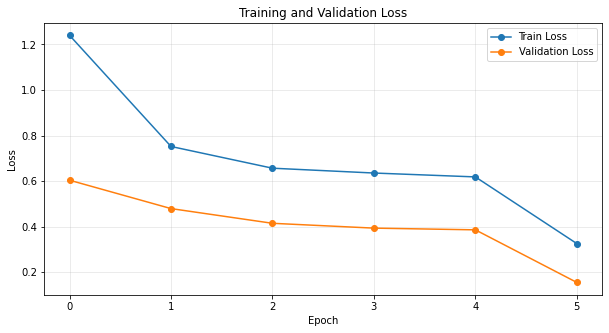

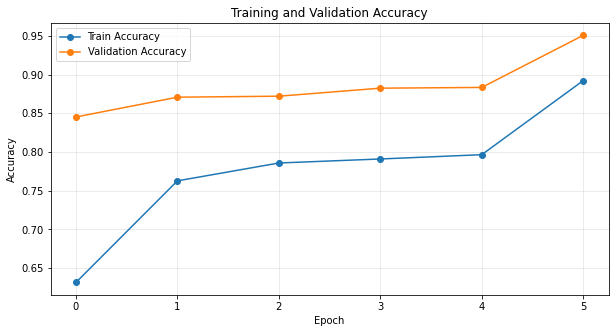

In [16]:
# CELL 12: Training curves

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

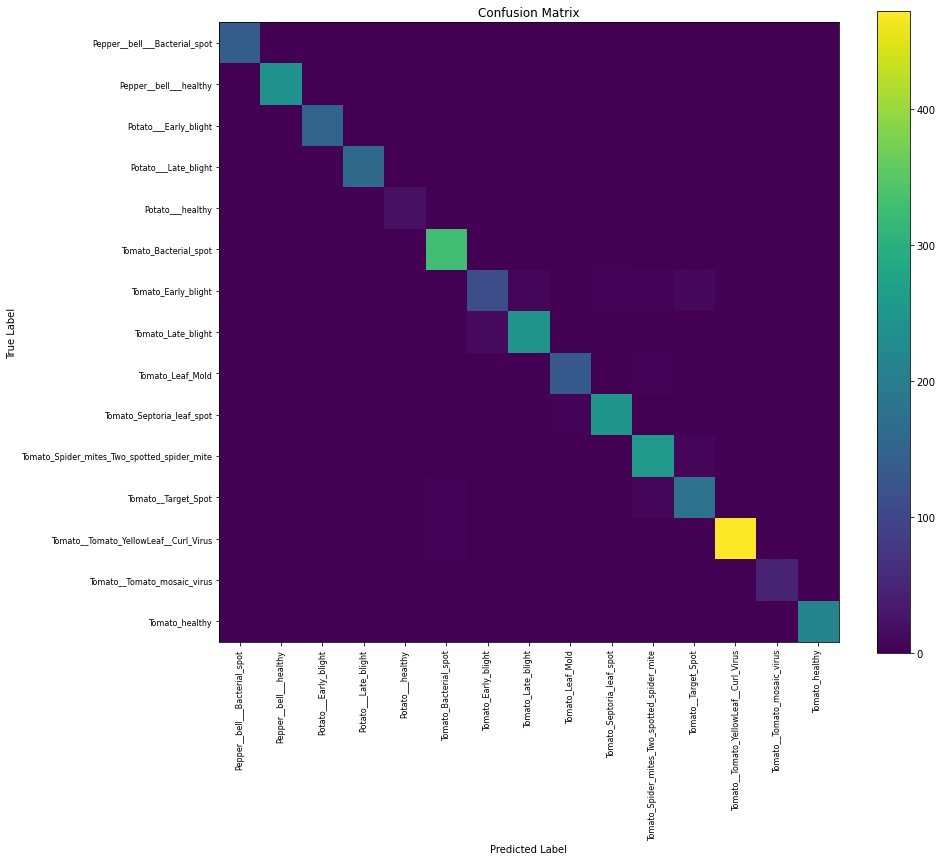

In [17]:
# CELL 13: Confusion matrix

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

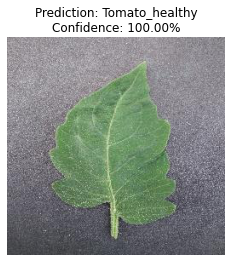

('Tomato_healthy', 0.9999990463256836)

In [24]:
# CELL 14: Predict one image

from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_idx = probs.max(dim=1)

    predicted_class = class_names[pred_idx.item()]
    confidence = confidence.item()

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.show()

    return predicted_class, confidence

# Example:
predict_image(r"C:\Users\santosh\Downloads\data\PlantVillage\Tomato_healthy\f2f5162b-7cc7-4315-8692-d1eaab98c554___GH_HL Leaf 507.2.JPG")

In [19]:
# CELL 15: Save final summary

summary = {
    "model": "ResNet18 Transfer Learning",
    "num_classes": num_classes,
    "train_samples": len(train_subset_aug),
    "validation_samples": len(val_subset),
    "test_samples": len(test_subset),
    "test_accuracy": test_acc,
    "test_loss": test_loss,
    "weighted_precision": precision_score(test_labels, test_preds, average="weighted", zero_division=0),
    "weighted_recall": recall_score(test_labels, test_preds, average="weighted", zero_division=0),
    "weighted_f1": f1_score(test_labels, test_preds, average="weighted", zero_division=0)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("plant_disease_results_summary.csv", index=False)
summary_df

,model,num_classes,train_samples,validation_samples,test_samples,test_accuracy,test_loss,weighted_precision,weighted_recall,weighted_f1
0,ResNet18 Transfer Learning,15,14446,3095,3097,0.951566,0.142201,0.951266,0.951566,0.951098
